# Pit Stop Submission Blender: Linear + H-Blend Research

This notebook creates a compact set of final blend candidates for the F1 pit stop prediction task. It uses the structured `blend_dataset` with public submissions, new top external submissions, and our own CatBoost outputs.

The baseline is still the proven `b10` recipe: `0.950 public_core + 0.050 public_0.95381`. The new experiment adds the h-blend idea from the external high-blend notebook: a row-wise rank-aware blend where submission weights depend on their relative prediction order for each row. This lets us test a different blending mechanism without producing a large number of files.

The output is intentionally small and separated by method: linear baselines, h-blend candidates, and hybrid candidates that mix top external predictions with h-blend corrections.


In [1]:
"""Import libraries, configure paths, and define notebook display helpers."""

from pathlib import Path
from html import escape
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None
from IPython.display import display, HTML

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")
if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("ggplot")

ID_COL = "id"
TARGET_COL = "PitNextLap"
CLIP_LOW = 1e-7
CLIP_HIGH = 1 - 1e-7

DATASET_CANDIDATES = [
    Path("/kaggle/input/pitstop-blend-inputs"),
    Path("/kaggle/input/pit-stop-blend-inputs"),
    Path("/kaggle/input/blend-dataset"),
    Path("/kaggle/input") / "blend_dataset",
    Path("PredictingPitStop/blend_dataset"),
    Path("blend_dataset"),
]

OUTPUT_ROOT = Path("outputs") / "blender"
SUBMISSION_ROOT = OUTPUT_ROOT / "submissions"
REPORT_ROOT = OUTPUT_ROOT / "reports"
for folder in [SUBMISSION_ROOT / "best", SUBMISSION_ROOT / "top_external", SUBMISSION_ROOT / "hblend", SUBMISSION_ROOT / "hybrid", SUBMISSION_ROOT / "public_support", REPORT_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)


def find_dataset_dir():
    for path in DATASET_CANDIDATES:
        if (path / "public").exists() and (path / "ours").exists():
            return path
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for path in sorted(kaggle_input.rglob("*")):
            if path.is_dir() and (path / "public").exists() and (path / "ours").exists():
                return path
    raise FileNotFoundError("Could not find a dataset folder containing public/ and ours/ subfolders.")


def fmt_value(value):
    if pd.isna(value):
        return "-"
    if isinstance(value, (np.integer, int)):
        return f"{int(value):,}"
    if isinstance(value, (np.floating, float)):
        if abs(value) >= 1000:
            return f"{value:,.0f}"
        return f"{value:.6f}".rstrip("0").rstrip(".")
    return str(value)


def show_title(title, subtitle=None):
    subtitle_html = f'<div style="color:#6b7280;font-size:13px;margin-top:3px;">{escape(str(subtitle))}</div>' if subtitle else ""
    display(HTML(
        f"""
        <div style="margin:18px 0 10px 0;padding-bottom:8px;border-bottom:1px solid #e5e7eb;">
          <div style="font-size:18px;font-weight:700;color:#111827;">{escape(str(title))}</div>
          {subtitle_html}
        </div>
        """
    ))


def show_metric_cards(title, data, columns=4):
    cards = []
    for key, value in data.items():
        cards.append(
            f"""
            <div style="border:1px solid #e5e7eb;border-radius:8px;padding:10px 12px;background:#ffffff;">
              <div style="font-size:11px;text-transform:uppercase;letter-spacing:.04em;color:#6b7280;">{escape(str(key).replace('_', ' '))}</div>
              <div style="font-size:18px;font-weight:700;color:#111827;margin-top:4px;">{escape(fmt_value(value))}</div>
            </div>
            """
        )
    display(HTML(
        f"""
        <div style="margin:12px 0;">
          <div style="font-size:15px;font-weight:700;color:#111827;margin-bottom:8px;">{escape(str(title))}</div>
          <div style="display:grid;grid-template-columns:repeat({columns},minmax(0,1fr));gap:8px;">
            {''.join(cards)}
          </div>
        </div>
        """
    ))


def show_table(title, df, max_rows=20):
    view = df.head(max_rows).copy()
    display(HTML(
        f"""
        <div style="margin:12px 0;max-width:1180px;">
          <div style="font-size:15px;font-weight:700;color:#111827;margin-bottom:8px;">{escape(str(title))}</div>
          {view.to_html(index=False, escape=False, classes='clean-table')}
        </div>
        <style>
          table.clean-table {{border-collapse:collapse;width:100%;font-size:13px;table-layout:auto;}}
          table.clean-table th {{background:#f9fafb;text-align:left;border-bottom:1px solid #e5e7eb;padding:8px;color:#374151;white-space:nowrap;}}
          table.clean-table td {{border-bottom:1px solid #eef2f7;padding:8px;color:#111827;vertical-align:top;}}
          table.clean-table td code {{font-size:12px;}}
        </style>
        """
    ))


## 1. Load Structured Blend Dataset

The loader reads only the structured dataset folders. This keeps the experiment clean: no old notebook outputs, no sample submissions, and no accidental duplicate files. The folder names define the role of each submission: `top_external`, `core`, `diverse`, `support`, `main`, or `variants`.


In [2]:
"""Load public and own submission files from the structured blend dataset."""

dataset_dir = find_dataset_dir()

predictions = {}
records = []
base_ids = None


def load_submission(path, source):
    global base_ids
    df = pd.read_csv(path)
    if ID_COL not in df.columns:
        return None
    target_candidates = [col for col in df.columns if col != ID_COL]
    if TARGET_COL in df.columns:
        target_col = TARGET_COL
    elif len(target_candidates) == 1:
        target_col = target_candidates[0]
    else:
        return None

    df = df[[ID_COL, target_col]].rename(columns={target_col: TARGET_COL})
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    if df[TARGET_COL].isna().any() or df[ID_COL].duplicated().any():
        return None

    if base_ids is None:
        base_ids = df[ID_COL].copy()
    elif not base_ids.equals(df[ID_COL]):
        return None

    safe_name = path.stem.replace(".", "_").replace("-", "_")
    name = f"{source}_{safe_name}"
    pred = np.clip(df[TARGET_COL].to_numpy(dtype=float), CLIP_LOW, CLIP_HIGH)
    predictions[name] = pred
    public_score = np.nan
    if source == "public":
        try:
            public_score = float(path.stem)
        except ValueError:
            public_score = np.nan
    return {
        "name": name,
        "source": source,
        "public_score": public_score,
        "group": path.parent.name,
        "rows": len(df),
        "mean": pred.mean(),
        "std": pred.std(),
        "file": str(path.relative_to(dataset_dir)),
    }

for source in ["public", "ours"]:
    for path in sorted((dataset_dir / source).rglob("*.csv")):
        row = load_submission(path, source)
        if row is not None:
            records.append(row)

if not records:
    raise FileNotFoundError("No valid submissions were loaded from the structured dataset.")

input_summary = pd.DataFrame(records).sort_values(["source", "group", "public_score", "name"], ascending=[True, True, False, True]).reset_index(drop=True)
input_summary.to_csv(REPORT_ROOT / "inputs.csv", index=False)

show_title("Loaded blend dataset", f"Dataset folder: {dataset_dir}")
show_metric_cards(
    "Input files",
    {
        "total": len(input_summary),
        "public": int(input_summary["source"].eq("public").sum()),
        "ours": int(input_summary["source"].eq("ours").sum()),
        "rows": len(base_ids),
    },
    columns=4,
)
show_table("Loaded submissions", input_summary[["name", "source", "group", "public_score", "mean", "std", "file"]].round(6), max_rows=30)


name,source,group,public_score,mean,std,file
ours_base,ours,main,NaN,0.276797,0.361970,ours/main/base.csv
ours_prob,ours,main,NaN,0.276541,0.362038,ours/main/prob.csv
ours_s42,ours,main,NaN,0.276623,0.362434,ours/main/s42.csv
ours_s777,ours,main,NaN,0.276787,0.361862,ours/main/s777.csv
ours_reg,ours,variants,NaN,0.279956,0.362559,ours/variants/reg.csv
ours_shallow,ours,variants,NaN,0.285043,0.364456,ours/variants/shallow.csv
public_0_95405,public,core,0.954050,0.219467,0.316353,public/core/0.95405.csv
public_0_95404,public,core,0.954040,0.222861,0.318378,public/core/0.95404.csv
public_0_95402,public,core,0.954020,0.226254,0.320474,public/core/0.95402.csv
public_0_95401,public,core,0.954010,0.213334,0.312760,public/core/0.95401.csv


## 2. Build Blend Groups

The groups are built from the folder structure. `public/core` remains the old stable core used by `b10`, while `public/top_external` contains the new `0.95409` candidates. Keeping those groups separate lets us compare the old proven recipe against the new stronger external signals.


In [3]:
"""Build the small set of groups used by the final blend candidates."""

public_meta = input_summary[input_summary["source"].eq("public") & input_summary["public_score"].notna()].copy()
public_meta = public_meta.sort_values("public_score", ascending=False)

top_external = input_summary[input_summary["group"].eq("top_external")]["name"].tolist()
public_core = input_summary[input_summary["group"].eq("core")].sort_values("public_score", ascending=False)["name"].head(6).tolist()
if not public_core:
    public_core = public_meta[public_meta["public_score"].ge(0.95388)].head(6)["name"].tolist()
if len(public_core) < 6 and not top_external:
    public_core = public_meta.head(6)["name"].tolist()


def public_by_score(score):
    matches = input_summary[
        input_summary["source"].eq("public")
        & np.isclose(input_summary["public_score"].astype(float), score, atol=1e-8, equal_nan=False)
    ]["name"].tolist()
    return matches

public_diverse = input_summary[input_summary["group"].eq("diverse")]["name"].tolist() or public_by_score(0.95381)
public_support = input_summary[input_summary["group"].eq("support")]["name"].tolist() or public_by_score(0.95305)
own_base = input_summary[input_summary["source"].eq("ours") & input_summary["group"].eq("main")]["name"].tolist()
own_variants = input_summary[input_summary["source"].eq("ours") & input_summary["group"].eq("variants")]["name"].tolist()

if not public_core:
    raise RuntimeError("public_core is empty.")
if not public_diverse:
    raise RuntimeError("Required public 0.95381 file was not found.")

groups = {
    "top_external": top_external,
    "public_core": public_core,
    "public_diverse": public_diverse,
    "public_support": public_support,
    "own_base": own_base,
    "own_variants": own_variants,
}

group_summary = pd.DataFrame(
    [{"group": group, "count": len(names), "members": ", ".join(names) or "-"} for group, names in groups.items()]
)
group_summary.to_csv(REPORT_ROOT / "groups.csv", index=False)

show_title("Blend groups", "Only the files used by final candidates are selected")
show_table("Groups", group_summary, max_rows=len(group_summary))


group,count,members
top_external,2,"public_0_95409_a, public_0_95409_b"
public_core,6,"public_0_95405, public_0_95404, public_0_95402, public_0_95401, public_0_95400, public_0_95388"
public_diverse,1,public_0_95381
public_support,2,"public_0_95356, public_0_95305"
own_base,4,"ours_base, ours_prob, ours_s42, ours_s777"
own_variants,2,"ours_reg, ours_shallow"


## 3. Create Linear, H-Blend, and Hybrid Candidates

This block creates a small, controlled output set. `b10` is the known baseline. `tx` and `tb` use the new top external submissions with ordinary linear blending. `hb1` and `hb2` use row-wise rank-aware h-blending. `hm1` and `hm2` mix the new top external signal with h-blend corrections. `ds` is kept as a tiny public-support control candidate.


In [4]:
"""Create compact linear, h-blend, and hybrid candidates with grouped output files."""


def mean_predictions(names):
    return np.clip(np.vstack([predictions[name] for name in names]).mean(axis=0), CLIP_LOW, CLIP_HIGH)


def save_submission(path, pred):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({ID_COL: base_ids.values, TARGET_COL: np.clip(pred, CLIP_LOW, CLIP_HIGH)}).to_csv(path, index=False)


def public_name_by_score(score):
    matches = input_summary[
        input_summary["source"].eq("public")
        & np.isclose(input_summary["public_score"].astype(float), score, atol=1e-8, equal_nan=False)
    ]["name"].tolist()
    return matches[0] if matches else None


def make_hblend(names, base_weights, rank_adjustments, desc_weight=0.70):
    matrix = np.vstack([predictions[name] for name in names]).T
    desc_order = np.argsort(-matrix, axis=1)
    asc_order = np.argsort(matrix, axis=1)
    base = np.asarray(base_weights, dtype=float)
    adjust = np.asarray(rank_adjustments, dtype=float)

    def weighted_by_order(order):
        out = np.zeros(matrix.shape[0], dtype=float)
        for rank_idx in range(matrix.shape[1]):
            col_idx = order[:, rank_idx]
            weights = base[col_idx] + adjust[rank_idx]
            out += matrix[np.arange(matrix.shape[0]), col_idx] * weights
        return out

    desc_part = weighted_by_order(desc_order)
    asc_part = weighted_by_order(asc_order)
    return np.clip(desc_weight * desc_part + (1 - desc_weight) * asc_part, CLIP_LOW, CLIP_HIGH)

core_pred = mean_predictions(groups["public_core"])
diverse_pred = predictions[groups["public_diverse"][0]]
support_pred = predictions[groups["public_support"][0]] if groups["public_support"] else None
top_external_pred = mean_predictions(groups["top_external"]) if groups.get("top_external") else None

blend_predictions = {}
blend_specs = []


def add_candidate(key, method, folder, filename, pred, recipe, note, try_order):
    pred = np.clip(pred, CLIP_LOW, CLIP_HIGH)
    blend_predictions[key] = pred
    path = SUBMISSION_ROOT / folder / filename
    save_submission(path, pred)
    blend_specs.append(
        {
            "try": try_order,
            "key": key,
            "method": method,
            "group": folder,
            "file": str(path.relative_to(OUTPUT_ROOT)),
            "recipe": recipe,
            "corr_b10": np.nan,
            "corr_tx": np.nan,
            "delta_b10": np.nan,
            "delta_tx": np.nan,
            "delta_core": np.abs(pred - core_pred).mean(),
            "mean": pred.mean(),
            "std": pred.std(),
            "note": note,
        }
    )

b10_pred = 0.950 * core_pred + 0.050 * diverse_pred
add_candidate("b10", "linear", "best", "b10.csv", b10_pred, "0.950 core + 0.050 95381", "Current best known recipe", 1)

try_order = 2
if top_external_pred is not None:
    add_candidate("tx", "linear", "top_external", "tx.csv", top_external_pred, "mean(0.95409_a, 0.95409_b)", "Mean of new 0.95409 external submissions", try_order)
    try_order += 1
    tb_pred = 0.900 * top_external_pred + 0.100 * b10_pred
    add_candidate("tb", "linear", "top_external", "tb.csv", tb_pred, "0.900 top_external + 0.100 b10", "Conservative top external + b10 blend", try_order)
    try_order += 1

    hblend_names = groups["top_external"][:2]
    for score in [0.95405, 0.95381]:
        name = public_name_by_score(score)
        if name is not None:
            hblend_names.append(name)

    if len(hblend_names) >= 4:
        hb1_pred = make_hblend(
            hblend_names[:4],
            base_weights=[0.38, 0.32, 0.20, 0.10],
            rank_adjustments=[0.02, 0.04, -0.10, 0.04],
            desc_weight=0.70,
        )
        add_candidate("hb1", "hblend", "hblend", "hb1.csv", hb1_pred, "rank-aware: top_a/top_b/95405/95381", "Row-wise h-blend with bolder rank corrections", try_order)
        try_order += 1

        hb2_pred = make_hblend(
            hblend_names[:4],
            base_weights=[0.45, 0.35, 0.15, 0.05],
            rank_adjustments=[0.01, 0.03, -0.07, 0.03],
            desc_weight=0.70,
        )
        add_candidate("hb2", "hblend", "hblend", "hb2.csv", hb2_pred, "rank-aware conservative: top_a/top_b/95405/95381", "Row-wise h-blend with conservative rank corrections", try_order)
        try_order += 1

        hm1_pred = 0.800 * top_external_pred + 0.200 * hb1_pred
        add_candidate("hm1", "hybrid", "hybrid", "hm1.csv", hm1_pred, "0.800 tx + 0.200 hb1", "Hybrid of top external mean and h-blend", try_order)
        try_order += 1

        hm2_pred = 0.850 * tb_pred + 0.150 * hb1_pred
        add_candidate("hm2", "hybrid", "hybrid", "hm2.csv", hm2_pred, "0.850 tb + 0.150 hb1", "Hybrid of conservative top external blend and h-blend", try_order)
        try_order += 1

if support_pred is not None:
    ds_pred = 0.945 * core_pred + 0.050 * diverse_pred + 0.005 * support_pred
    add_candidate("ds", "linear", "public_support", "ds.csv", ds_pred, "0.945 core + 0.050 95381 + 0.005 95305", "Tiny public-support control candidate", try_order)
    try_order += 1

b10 = blend_predictions["b10"]
tx = blend_predictions.get("tx", b10)
for row in blend_specs:
    pred = blend_predictions[row["key"]]
    row["corr_b10"] = np.corrcoef(pred, b10)[0, 1]
    row["corr_tx"] = np.corrcoef(pred, tx)[0, 1]
    row["delta_b10"] = np.abs(pred - b10).mean()
    row["delta_tx"] = np.abs(pred - tx).mean()

blend_summary = pd.DataFrame(blend_specs).sort_values("try").reset_index(drop=True)
blend_summary.to_csv(REPORT_ROOT / "blend_summary.csv", index=False)
readable_summary = blend_summary[["try", "key", "method", "group", "file", "recipe", "corr_b10", "corr_tx", "delta_b10", "delta_tx", "delta_core", "note"]].round(6)
readable_summary.to_csv(REPORT_ROOT / "blend_summary_readable.csv", index=False)

save_submission(OUTPUT_ROOT / "submission.csv", b10)

show_title("Final blend candidates", "Linear baselines, h-blend candidates, and hybrid candidates")
show_table("Candidates", readable_summary, max_rows=len(readable_summary))
show_metric_cards(
    "Output files",
    {
        "candidates": len(blend_summary),
        "default": "b10",
        "folder": str(SUBMISSION_ROOT),
    },
    columns=3,
)


try,key,method,group,file,recipe,corr_b10,corr_tx,delta_b10,delta_tx,delta_core,note
1,b10,linear,best,submissions/best/b10.csv,0.950 core + 0.050 95381,1.000000,0.997789,0.000000,0.026019,0.014052,Current best known recipe
2,tx,linear,top_external,submissions/top_external/tx.csv,"mean(0.95409_a, 0.95409_b)",0.997789,1.000000,0.026019,0.000000,0.012255,Mean of new 0.95409 external submissions
3,tb,linear,top_external,submissions/top_external/tb.csv,0.900 top_external + 0.100 b10,0.998212,0.999978,0.023417,0.002602,0.009778,Conservative top external + b10 blend
4,hb1,hblend,hblend,submissions/hblend/hb1.csv,rank-aware: top_a/top_b/95405/95381,0.999104,0.997405,0.017697,0.039246,0.029732,Row-wise h-blend with bolder rank corrections
5,hb2,hblend,hblend,submissions/hblend/hb2.csv,rank-aware conservative: top_a/top_b/95405/95381,0.999222,0.999236,0.008228,0.021234,0.015817,Row-wise h-blend with conservative rank corrections
6,hm1,hybrid,hybrid,submissions/hybrid/hm1.csv,0.800 tx + 0.200 hb1,0.998456,0.999900,0.018253,0.007849,0.010417,Hybrid of top external mean and h-blend
7,hm2,hybrid,hybrid,submissions/hybrid/hm2.csv,0.850 tb + 0.150 hb1,0.998622,0.999878,0.017980,0.008083,0.009633,Hybrid of conservative top external blend and h-blend
8,ds,linear,public_support,submissions/public_support/ds.csv,0.945 core + 0.050 95381 + 0.005 95305,1.000000,0.997808,0.000107,0.025919,0.013950,Tiny public-support control candidate


## 4. Compare Candidate Movement

The chart compares how far each candidate moves from `b10`, `tx`, and the old public core. Large movement is not automatically bad, because the new `0.95409` files are stronger than the old baseline, but it helps us choose which submissions are conservative and which are more experimental.


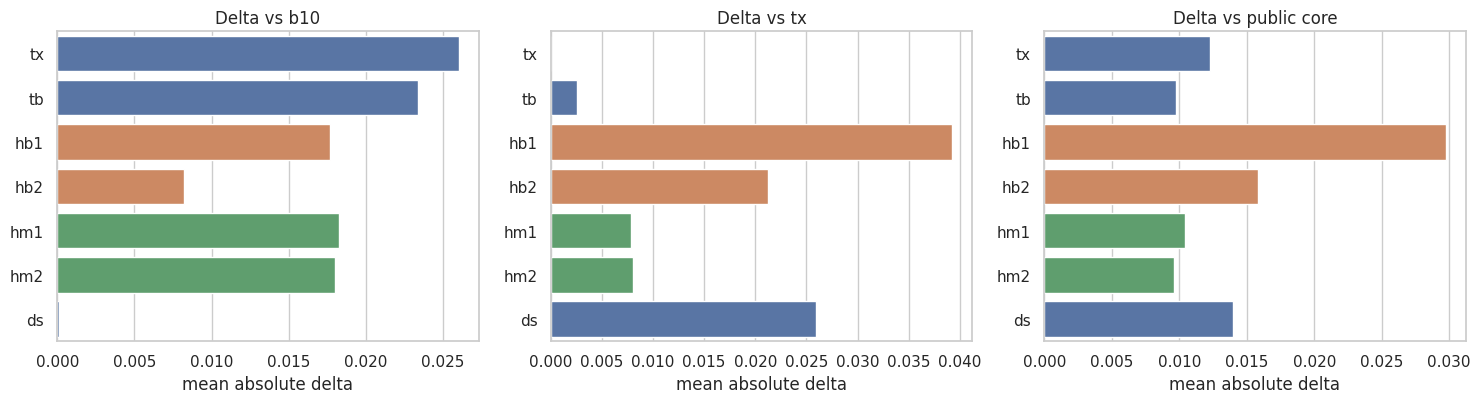

try,key,method,file,recipe,delta_b10,delta_tx,note
1,b10,linear,submissions/best/b10.csv,0.950 core + 0.050 95381,0.000000,0.026019,Current best known recipe
2,tx,linear,submissions/top_external/tx.csv,"mean(0.95409_a, 0.95409_b)",0.026019,0.000000,Mean of new 0.95409 external submissions
3,tb,linear,submissions/top_external/tb.csv,0.900 top_external + 0.100 b10,0.023417,0.002602,Conservative top external + b10 blend
4,hb1,hblend,submissions/hblend/hb1.csv,rank-aware: top_a/top_b/95405/95381,0.017697,0.039246,Row-wise h-blend with bolder rank corrections
5,hb2,hblend,submissions/hblend/hb2.csv,rank-aware conservative: top_a/top_b/95405/95381,0.008228,0.021234,Row-wise h-blend with conservative rank corrections
6,hm1,hybrid,submissions/hybrid/hm1.csv,0.800 tx + 0.200 hb1,0.018253,0.007849,Hybrid of top external mean and h-blend
7,hm2,hybrid,submissions/hybrid/hm2.csv,0.850 tb + 0.150 hb1,0.017980,0.008083,Hybrid of conservative top external blend and h-blend
8,ds,linear,submissions/public_support/ds.csv,0.945 core + 0.050 95381 + 0.005 95305,0.000107,0.025919,Tiny public-support control candidate


In [5]:
"""Visualize how far each candidate moves from b10, tx, and the old public core."""

plot_df = readable_summary.copy()
plot_df = plot_df[plot_df["key"] != "b10"].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
if len(plot_df):
    if sns is not None:
        sns.barplot(data=plot_df, y="key", x="delta_b10", hue="method", dodge=False, ax=axes[0])
        sns.barplot(data=plot_df, y="key", x="delta_tx", hue="method", dodge=False, ax=axes[1])
        sns.barplot(data=plot_df, y="key", x="delta_core", hue="method", dodge=False, ax=axes[2])
        for ax in axes:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
    else:
        axes[0].barh(plot_df["key"], plot_df["delta_b10"])
        axes[1].barh(plot_df["key"], plot_df["delta_tx"])
        axes[2].barh(plot_df["key"], plot_df["delta_core"])
axes[0].set_title("Delta vs b10")
axes[1].set_title("Delta vs tx")
axes[2].set_title("Delta vs public core")
for ax in axes:
    ax.set_xlabel("mean absolute delta")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

show_table("Submission priority", readable_summary[["try", "key", "method", "file", "recipe", "delta_b10", "delta_tx", "note"]], max_rows=len(readable_summary))
